In [1]:
from pipeline import Pipeline
import logging
from colorlog import ColoredFormatter

def setup_logger():
    logger = logging.getLogger("pipeline")
    logger.setLevel(logging.DEBUG)

    handler = logging.StreamHandler()

    formatter = ColoredFormatter(
        "%(log_color)s%(asctime)s | %(levelname)s | %(message)s",
        log_colors={
            "DEBUG": "green",     # inside functions
            "INFO": "blue",       # pipeline-level info
            "WARNING": "yellow",
            "ERROR": "red",
            "CRITICAL": "red,bg_white",
        },
    )

    handler.setFormatter(formatter)
    logger.addHandler(handler)
    logger.propagate = False
    return logger

In [2]:
def main():
    logger = setup_logger()

    pipeline = Pipeline(
        fits_dir="2024-07-29/sun_area/SlitJaw",
        hdf_dir="data/hdf",
        flat_dir="data/flats",
        dark_dir="data/darks",
        output_dir="output",
        logger=logger,
    )

    pipeline.run()

2026-02-11 12:53:39,539 | INFO | Pipeline started
2026-02-11 12:53:39,542 | INFO | Loading data
2026-02-11 12:53:40,743 | DEBUG | Loaded 109 FITS files from 2024-07-29/sun_area/SlitJaw


  Reading HDF5 from data/hdf
  Reading flats from data/flats
  Reading darks from data/darks


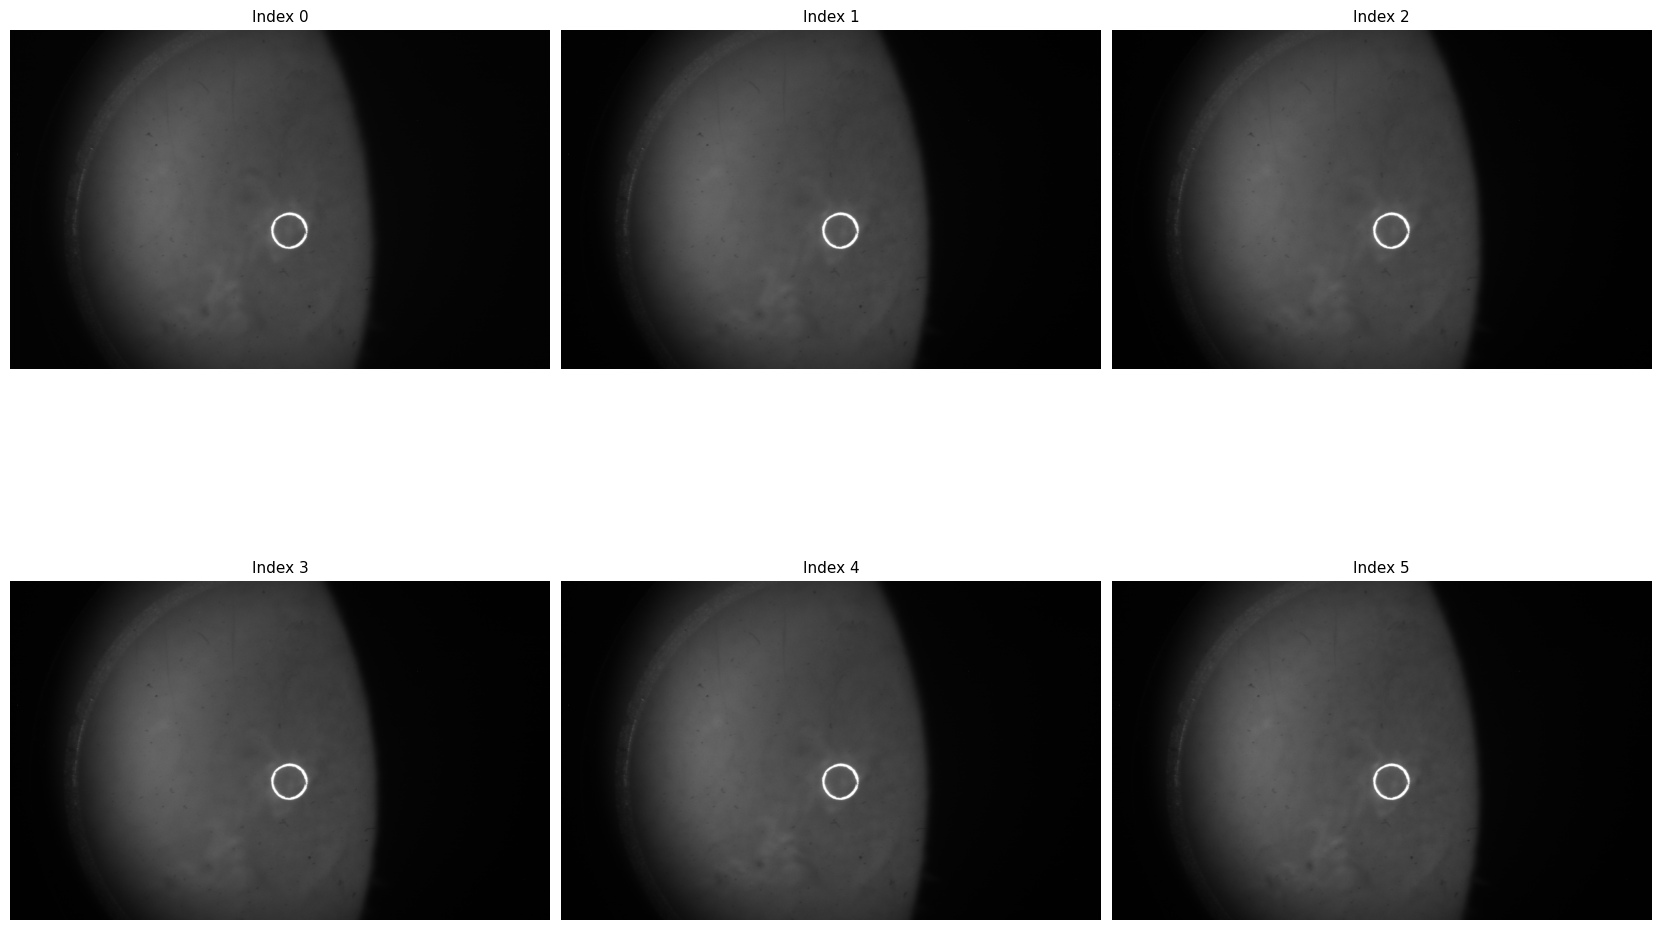

2026-02-11 12:53:47,668 | INFO | Processing data
2026-02-11 12:53:47,674 | INFO | Releasing raw data from memory


  Applying calibration


2026-02-11 12:53:47,941 | INFO | Analyzing data
2026-02-11 12:53:47,944 | INFO | Plotting results
2026-02-11 12:53:47,947 | INFO | Releasing calibrated data from memory
2026-02-11 12:53:48,046 | INFO | Pipeline finished


  Running analysis
  Saving plots to output


In [3]:
main()